
## SQL in R Notebook

I have chosen 3 main problem areas that seem most important in the scenario:

1. Why do some zones perform worse than others?
2. Which service types are creating the biggest operational and customer problems?
3. Which hubs appear to be underperforming, and is there any structured evidence of why?

These were chosen because they come up repeatedly in the case study:
- management is unsure why some zones perform worse
- service quality varies across service types
- complaints are rising
- some hubs appear weak
- the business wants to understand where inefficiencies actually come from


## 1. Load packages


In [1]:
install.packages("sqldf")
library(sqldf)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



## 2. Load the cleaned datasets


In [2]:
orders <- read.csv("https://raw.githubusercontent.com/TaylorPendred/Datasets-and-Notebooks/main/cleaned_orders.csv")
deliveries <- read.csv("https://raw.githubusercontent.com/TaylorPendred/Datasets-and-Notebooks/main/cleaned_deliveries.csv")
complaints <- read.csv("https://raw.githubusercontent.com/TaylorPendred/Datasets-and-Notebooks/main/cleaned_complaints.csv")
hubs <- read.csv("https://raw.githubusercontent.com/TaylorPendred/Datasets-and-Notebooks/main/cleaned_hubs.csv")
incidents <- read.csv("https://raw.githubusercontent.com/TaylorPendred/Datasets-and-Notebooks/main/cleaned_incidents.csv")


## 3. Quick inspection


In [3]:
dim(orders)
dim(deliveries)
dim(complaints)
dim(hubs)
dim(incidents)


[1] 1250   11

[1] 950  13

[1] 320  10

[1] 8 5

[1] 280   7

# Problem Area 1: Some zones perform worse than others

The case study makes it clear that NorthStar does not understand why some zones perform worse than others.  
This is one of the most direct operational problems in the scenario, so I chose to start here.

To investigate this properly, I want to check:
- which zones carry the most order volume
- which zones show the most failed or delayed deliveries
- whether the weaker zones are still weak when delivery volume is taken into account


## 4. Query 1: Which pickup zones are most active?

### Why this query matters
Before deciding that a zone is weak, it helps to know how much work it is handling.  
A zone with more deliveries may naturally show more problems in raw totals.


In [4]:
zone_volume <- sqldf("
SELECT pickup_zone,
       COUNT(*) AS total_orders
FROM orders
GROUP BY pickup_zone
ORDER BY total_orders DESC
")

zone_volume


pickup_zone,total_orders
<chr>,<int>
Central,238
East,207
South,181
North,174
West,155
Riverside,151
Airport,144


### Result analysis
This query shows that Central is the busiest pickup zone, followed by East and South.
That means later weakness in Central cannot be judged from raw totals alone because it is also carrying the most demand.


## 5. Query 2: Which pickup zones show the weakest delivery outcomes?

### Why this query matters
The case study specifically raises the problem of uneven zone performance.  
This query directly compares delivery outcomes by pickup zone.


In [5]:
zone_outcomes <- sqldf("
SELECT o.pickup_zone,
       d.delivery_status,
       COUNT(*) AS total_records
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
GROUP BY o.pickup_zone, d.delivery_status
ORDER BY o.pickup_zone, total_records DESC
")

zone_outcomes


pickup_zone,delivery_status,total_records
<chr>,<chr>,<int>
Airport,OnTime,70
Airport,Delayed,31
Airport,Failed,12
Central,OnTime,90
Central,Delayed,51
Central,Failed,33
East,OnTime,106
East,Delayed,31
East,Failed,19


### R visual: delivery outcomes by pickup zone


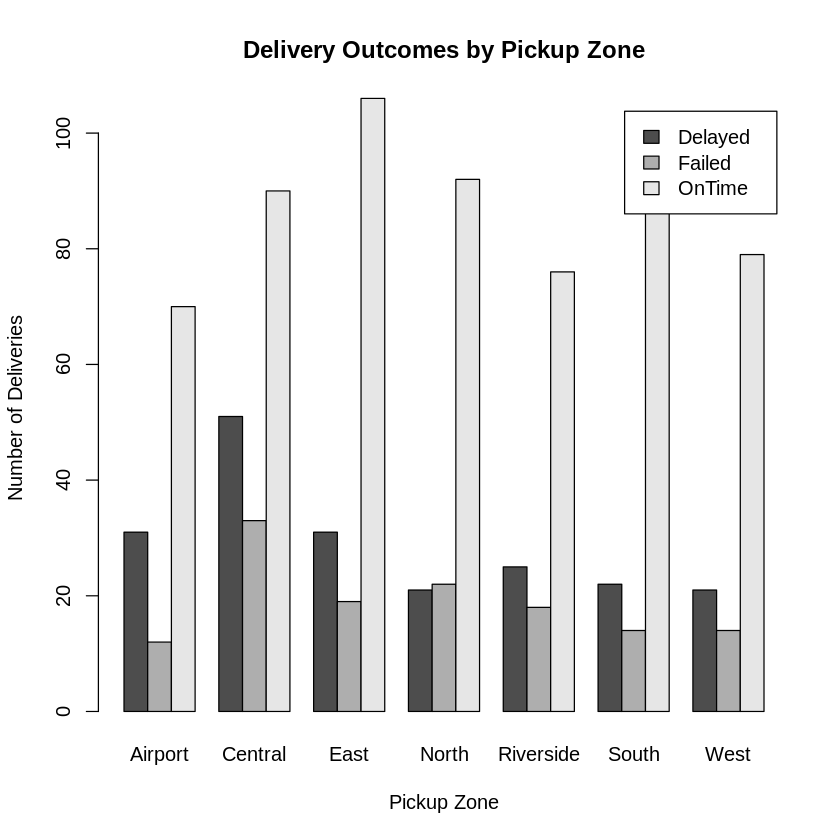

In [6]:
zone_matrix <- xtabs(total_records ~ pickup_zone + delivery_status, data = zone_outcomes)

barplot(
  t(zone_matrix),
  beside = TRUE,
  legend = TRUE,
  main = "Delivery Outcomes by Pickup Zone",
  xlab = "Pickup Zone",
  ylab = "Number of Deliveries"
)


### Result analysis
The results show that Central has the heaviest negative outcome burden in absolute terms, with the highest delayed and failed counts.  
East also shows noticeable weakness, and North stands out because failed deliveries are particularly high relative to its size.  
This supports the case study claim that the network is not performing evenly across locations.


## 6. Query 3: Are weak zones still weak when volume is taken into account?

### Why this query matters
Raw totals are useful, but rates are stronger because they show whether a zone is genuinely weaker rather than just busier.


In [7]:
zone_rates <- sqldf("
SELECT o.pickup_zone,
       COUNT(*) AS total_deliveries,
       SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,
       ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS failed_rate_pct,
       ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS delayed_rate_pct
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
GROUP BY o.pickup_zone
ORDER BY failed_rate_pct DESC, delayed_rate_pct DESC
")

zone_rates


pickup_zone,total_deliveries,failed_deliveries,delayed_deliveries,failed_rate_pct,delayed_rate_pct
<chr>,<int>,<int>,<int>,<dbl>,<dbl>
Central,174,33,51,18.97,29.31
North,135,22,21,16.30,15.56
Riverside,119,18,25,15.13,21.01
West,114,14,21,12.28,18.42
East,156,19,31,12.18,19.87
Airport,113,12,31,10.62,27.43
South,139,14,22,10.07,15.83


### R visual: failed delivery rate by pickup zone


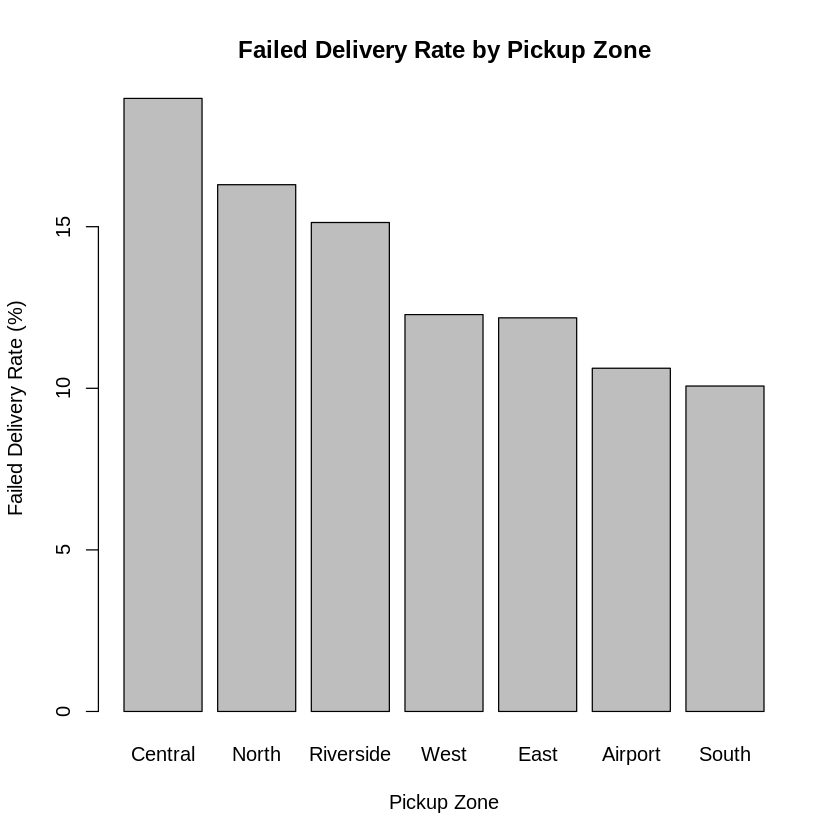

In [8]:
barplot(
  zone_rates$failed_rate_pct,
  names.arg = zone_rates$pickup_zone,
  main = "Failed Delivery Rate by Pickup Zone",
  xlab = "Pickup Zone",
  ylab = "Failed Delivery Rate (%)"
)


### Result analysis
When rates are used, North and Airport look especially fragile, while **Central** still remains important because it combines high volume with a high failure burden.  
This gives a stronger answer to the case study problem because it shows that some zones are genuinely weaker, not just busier.


# Problem Area 2: Some service types are creating bigger operational and customer problems

The case study says service quality varies across service types.  
It also highlights growing customer dissatisfaction, so I chose to combine service performance with complaint evidence.

To investigate this, I want to check:
- which service types are largest
- which service types show weak outcomes
- which service types generate the most complaints
- whether customer dissatisfaction lines up with weak service types


## 7. Query 4: Which service types carry the most operational volume?

### Why this query matters
This gives context before comparing performance and complaints.


In [9]:
service_volume <- sqldf("
SELECT service_type,
       COUNT(*) AS total_orders
FROM orders
GROUP BY service_type
ORDER BY total_orders DESC
")

service_volume


service_type,total_orders
<chr>,<int>
Passenger,341
Parcel,308
Retail,297
Business,165
Medical,139


### Result analysis
The biggest service types are Passenger, Parcel, and Retail.  
This matters because they will naturally generate more incidents or complaints in raw totals, so later interpretation has to consider both size and weakness.


## 8. Query 5: Which service types show the weakest delivery outcomes?

### Why this query matters
This directly tests whether some services are more operationally problematic than others.


In [10]:
service_outcomes <- sqldf("
SELECT o.service_type,
       d.delivery_status,
       COUNT(*) AS total_records
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
GROUP BY o.service_type, d.delivery_status
ORDER BY o.service_type, total_records DESC
")

service_outcomes


service_type,delivery_status,total_records
<chr>,<chr>,<int>
Business,OnTime,73
Business,Delayed,28
Business,Failed,25
Medical,OnTime,70
Medical,Delayed,22
Medical,Failed,16
Parcel,OnTime,156
Parcel,Delayed,49
Parcel,Failed,25


### R visual: delivery outcomes by service type


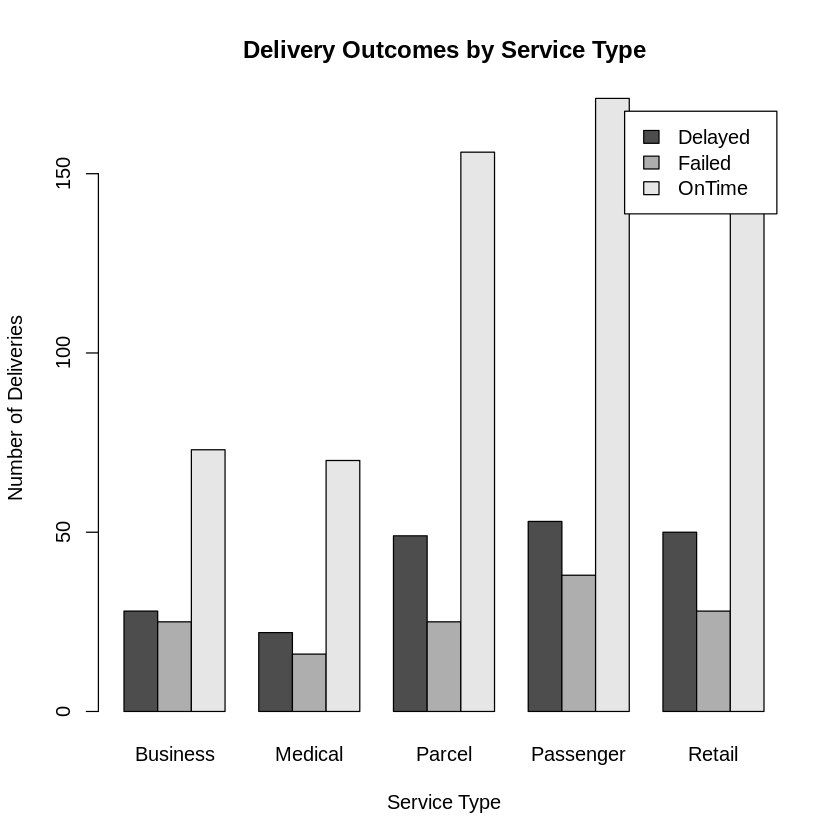

In [11]:
service_matrix <- xtabs(total_records ~ service_type + delivery_status, data = service_outcomes)

barplot(
  t(service_matrix),
  beside = TRUE,
  legend = TRUE,
  main = "Delivery Outcomes by Service Type",
  xlab = "Service Type",
  ylab = "Number of Deliveries"
)


### Result analysis
The largest negative outcome volumes are concentrated in Passenger, Retail, and Parcel.  
Passenger is the heaviest pressure point overall, while Retail and Parcel also show substantial delay and failure counts.  
This suggests that NorthStar’s service-quality problem is concentrated in a few major service lines rather than spread evenly.


## 9. Query 6: Which service types generate the most complaints?

### Why this query matters
The case study is not only about operations.  
It is also about customer dissatisfaction, so complaint evidence needs to be linked to service type.


In [12]:
service_complaints <- sqldf("
SELECT o.service_type,
       COUNT(c.complaint_id) AS total_complaints
FROM orders o
LEFT JOIN complaints c
ON o.order_id = c.order_id
GROUP BY o.service_type
ORDER BY total_complaints DESC
")

service_complaints


service_type,total_complaints
<chr>,<int>
Passenger,84
Retail,83
Parcel,77
Business,39
Medical,37


### R visual: complaints by service type


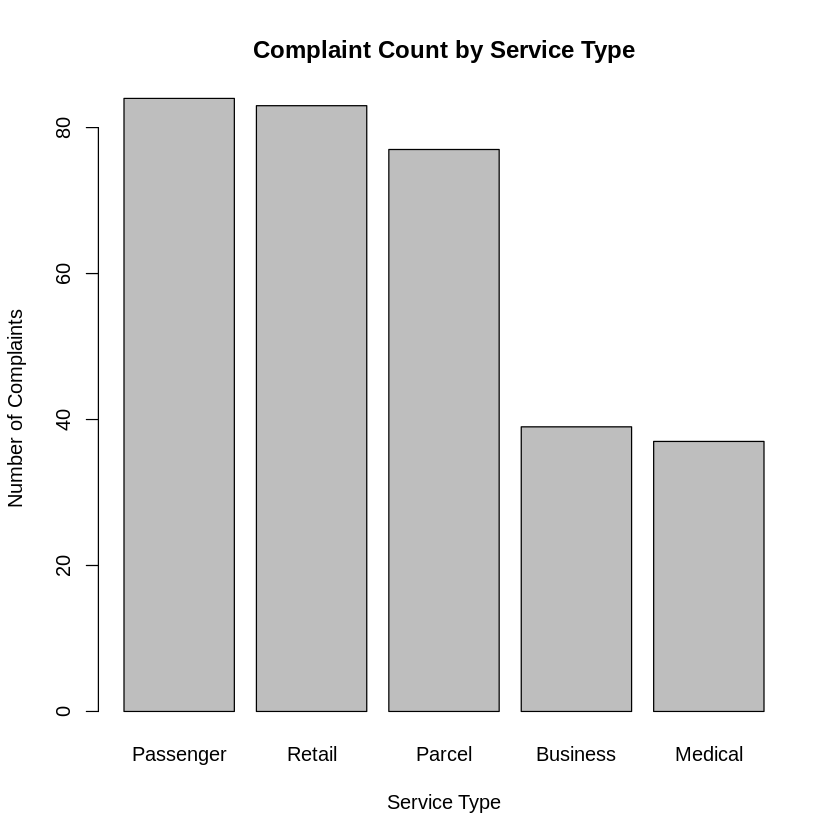

In [13]:
barplot(
  service_complaints$total_complaints,
  names.arg = service_complaints$service_type,
  main = "Complaint Count by Service Type",
  xlab = "Service Type",
  ylab = "Number of Complaints"
)


### Result analysis
The complaint results show that Passenger, Retail, and Parcel are again the main problem services.  
This is important because it means the same service types that show weak operational outcomes are also the ones generating the most customer dissatisfaction.  
That strengthens the view that these are the core service lines NorthStar needs to improve.


# Problem Area 3: Some hubs appear weak, and there may be structured signs of why

The case study suggests that underperforming hubs, route allocation issues, and operational disruption may be part of the problem.

I chose this problem area because it goes beyond symptoms and starts to address where inefficiencies might originate.

To investigate this, I want to check:
- which hubs look weakest on delivery outcomes
- whether route overrides are higher in weak outcomes
- whether incident volume is concentrated in the same hubs
- whether some hubs are also more costly


## 10. Query 7: Which hubs are underperforming on delivery outcomes?

### Why this query matters
The case study explicitly raises the possibility of weak hubs.  
This query checks whether some hubs have worse delivery outcomes than others.


In [14]:
hub_outcomes <- sqldf("
SELECT d.hub_id,
       h.hub_name,
       h.zone,
       d.delivery_status,
       COUNT(*) AS total_deliveries
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY d.hub_id, h.hub_name, h.zone, d.delivery_status
ORDER BY d.hub_id, total_deliveries DESC
")

hub_outcomes


hub_id,hub_name,zone,delivery_status,total_deliveries
<chr>,<chr>,<chr>,<chr>,<int>
H01,North Exchange,North,OnTime,93
H01,North Exchange,North,Delayed,26
H01,North Exchange,North,Failed,17
H02,South Link,South,OnTime,70
H02,South Link,South,Delayed,26
H02,South Link,South,Failed,10
H03,East Dock,East,OnTime,85
H03,East Dock,East,Delayed,23
H03,East Dock,East,Failed,11


### R visual: delivery outcomes by hub


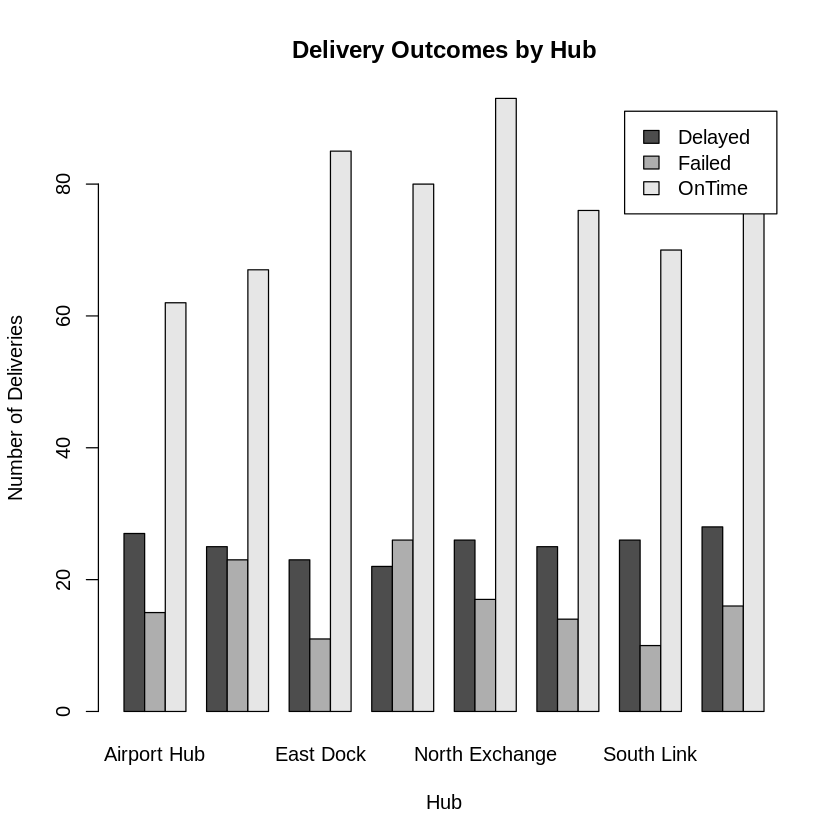

In [15]:
hub_matrix <- xtabs(total_deliveries ~ hub_name + delivery_status, data = hub_outcomes)

barplot(
  t(hub_matrix),
  beside = TRUE,
  legend = TRUE,
  main = "Delivery Outcomes by Hub",
  xlab = "Hub",
  ylab = "Number of Deliveries"
)


### Result analysis
The hub results suggest that H05 is one of the clearest underperformers, while H08 and H06 also show weaker outcomes.  
This is important because it gives a more specific operational target than simply saying the whole network is weak.


## 11. Query 8: Are manual route overrides higher in weaker delivery outcomes?

### Why this query matters
The case study mentions route allocation and manual intervention as possible problems.  
If weak deliveries show more overrides, that gives structured evidence for operational friction.


In [16]:
override_status <- sqldf("
SELECT delivery_status,
       ROUND(AVG(manual_route_override_count), 2) AS avg_override_count
FROM deliveries
GROUP BY delivery_status
ORDER BY avg_override_count DESC
")

override_status


delivery_status,avg_override_count
<chr>,<dbl>
Delayed,1.07
Failed,1.04
OnTime,0.92


### R visual: average route overrides by delivery status


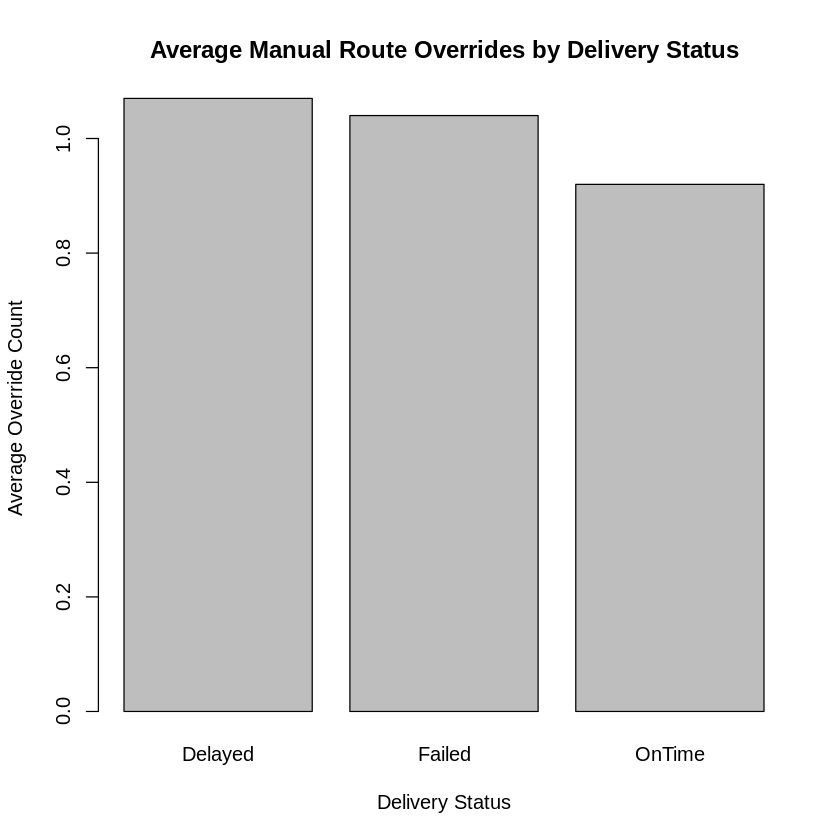

In [17]:
barplot(
  override_status$avg_override_count,
  names.arg = override_status$delivery_status,
  main = "Average Manual Route Overrides by Delivery Status",
  xlab = "Delivery Status",
  ylab = "Average Override Count"
)


### Result analysis
Delayed and Failed deliveries show slightly higher average override counts than OnTime deliveries.  
The difference is not huge, but it is consistent enough to suggest that route intervention is associated with weaker delivery outcomes.  
This helps move the notebook from description towards explanation.


## 12. Query 9: Are incidents concentrated in particular hubs?

### Why this query matters
If incidents cluster in the same hubs that already show weak outcomes, that is stronger evidence of a real operational hotspot.


In [18]:
incident_hub <- sqldf("
SELECT d.hub_id,
       h.hub_name,
       COUNT(i.incident_id) AS total_incidents
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
LEFT JOIN incidents i
ON d.delivery_id = i.delivery_id
GROUP BY d.hub_id, h.hub_name
ORDER BY total_incidents DESC
")

incident_hub


hub_id,hub_name,total_incidents
<chr>,<chr>,<int>
H05,Central Core,39
H03,East Dock,38
H08,Midtown Relay,38
H07,Riverside Hub,35
H04,West Gate,34
H02,South Link,33
H06,Airport Hub,32
H01,North Exchange,31


### R visual: incident count by hub


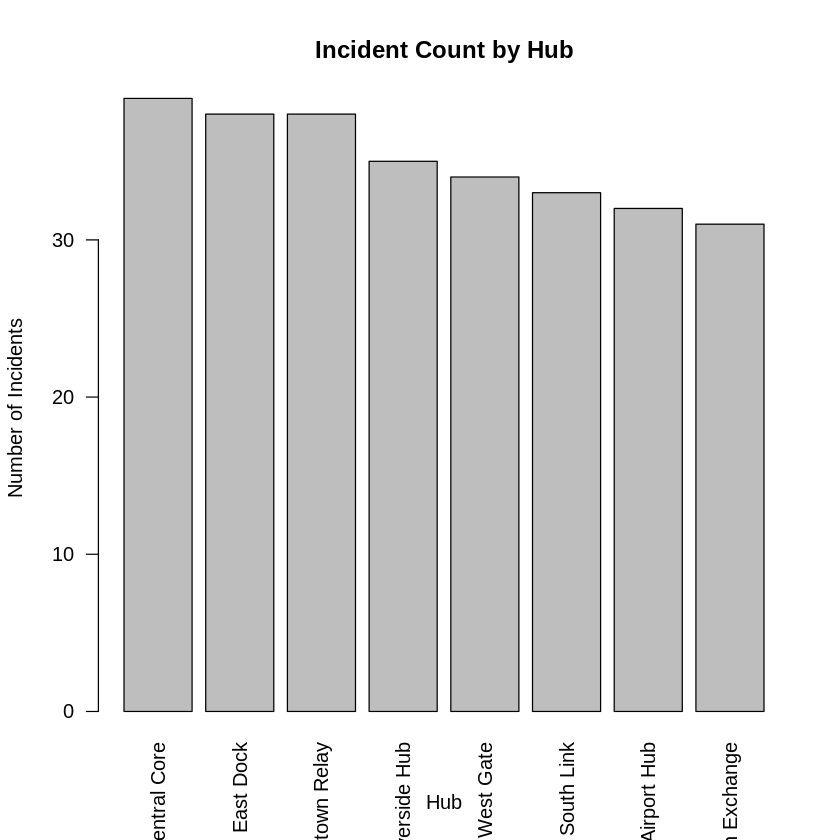

In [19]:
barplot(
  incident_hub$total_incidents,
  names.arg = incident_hub$hub_name,
  las = 2,
  main = "Incident Count by Hub",
  xlab = "Hub",
  ylab = "Number of Incidents"
)


### Result analysis
The incident results show that H05 again appears as a major concern.  
That matters because it supports the earlier hub analysis: H05 is not only weaker on delivery outcomes, it also has the highest incident burden.  
This makes it a more convincing operational hotspot.


## 13. Query 10: Are some hubs more costly than others?

### Why this query matters
The case study also raises profitability and cost concerns.  
A hub that is both weak and expensive is more serious than a hub that is only weak.


In [20]:
hub_costs <- sqldf("
SELECT h.hub_name,
       ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_delivery_cost
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.hub_name
ORDER BY avg_delivery_cost DESC
")

hub_costs


hub_name,avg_delivery_cost
<chr>,<dbl>
Central Core,13.69
Airport Hub,13.32
West Gate,13.17
Riverside Hub,12.92
North Exchange,12.76
East Dock,12.74
South Link,12.57
Midtown Relay,11.71


### R visual: average delivery cost by hub


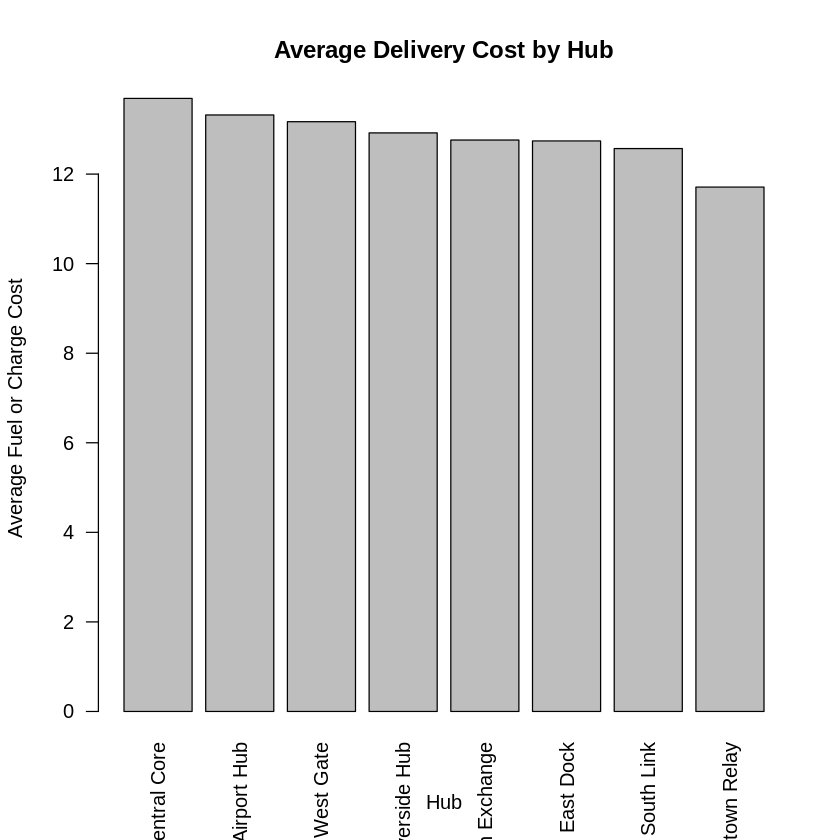

In [21]:
barplot(
  hub_costs$avg_delivery_cost,
  names.arg = hub_costs$hub_name,
  las = 2,
  main = "Average Delivery Cost by Hub",
  xlab = "Hub",
  ylab = "Average Fuel or Charge Cost"
)


### Result analysis
The cost analysis shows that Central Core is the most expensive hub on average.  
This matters because earlier results already suggested that Central is one of the weaker operating areas.  
That means cost risk and service weakness may be overlapping in the same part of the network.


## 14. Query 11: Do weak services also carry commercial risk?

### Why this query matters
It is useful to know whether the same service types that perform weakly are also commercially important.


In [22]:
service_value_cost <- sqldf("
SELECT o.service_type,
       COUNT(*) AS total_records,
       ROUND(AVG(o.order_value), 2) AS avg_order_value,
       ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_delivery_cost
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
GROUP BY o.service_type
ORDER BY avg_delivery_cost DESC
")

service_value_cost


service_type,total_records,avg_order_value,avg_delivery_cost
<chr>,<int>,<dbl>,<dbl>
Business,126,97.45,13.14
Parcel,230,90.15,13.08
Retail,224,86.81,12.97
Medical,108,86.53,12.77
Passenger,262,97.19,12.40


### R visual: average order value and delivery cost by service type


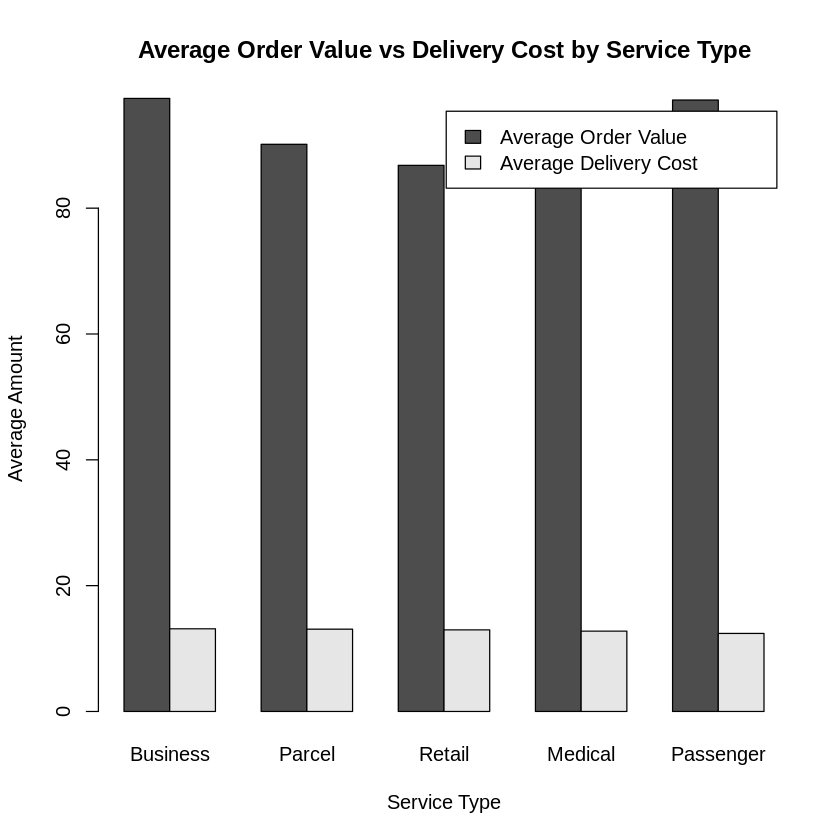

In [23]:
service_compare <- rbind(service_value_cost$avg_order_value, service_value_cost$avg_delivery_cost)

barplot(
  service_compare,
  beside = TRUE,
  names.arg = service_value_cost$service_type,
  legend.text = c("Average Order Value", "Average Delivery Cost"),
  main = "Average Order Value vs Delivery Cost by Service Type",
  xlab = "Service Type",
  ylab = "Average Amount"
)


### Result analysis
This final query shows that Passenger is not only one of the weakest services operationally, but also one of the most commercially important.  
That means poor performance in Passenger creates both service risk and business risk, which makes it a strong priority for management.


## 15. Final conclusion

I chose to focus this SQL in R notebook on 3 main problem areas from the case study:

1. zone performance
2. service type performance and customer dissatisfaction
3. hub weakness and possible operational causes

This smaller set of queries is enough to answer the most important structured questions without trying to analyse everything at once.

The main findings are:

- Central is the key weak zone in raw delivery counts, while North and Airpor also look fragile when failure rates are used.
- Passenger, Retail, and Parcel are the most important weak service types because they combine large volume with high delay, failure, and complaint counts.
- H05 stands out as a likely underperforming hub because it combines weak delivery outcomes with high incident volume.
- Route overrides are slightly higher in delayed and failed deliveries, which suggests some connection between weak outcomes and operational intervention.
- Central Core appears costly, and Passenger combines commercial importance with operational weakness.

Taken together, these results answer the most important structured problems in the case study and provide a strong foundation for the MongoDB work on more flexible operational records.
